### Bức tranh tổng thể


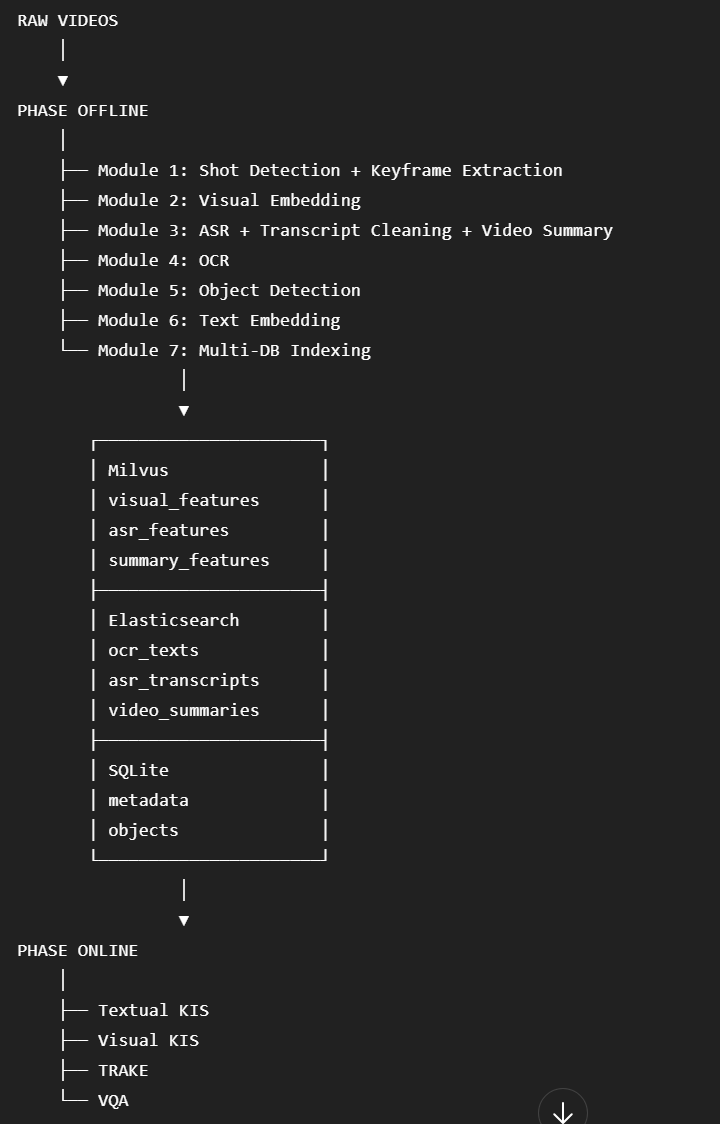

# 1. Bước 1: Shot Detection và Keyframe Extraction

Input: 
- Một video gốc: `data/raw_videos/<video_id>.mp4`. `video_id` hiện được tạo từ tên file video, bỏ phần mở rộng
- Ví dụ: data/raw_videos/V001.mp4 => `video_id` = "V001"

Xử lý:
- Video

→ TransNetV2 phát hiện shot

→ mỗi shot lấy 3 keyframe

→ vị trí 0.15, 0.50, 0.85 trong shot

→ lưu ảnh WebP

→ lưu metadata JSON

Output:
- Mỗi keyframe được lưu dưới dạng: `.webp`
- Dạng tên được code indexing kỳ vọng:
    - shot_00000_pos_015.webp
    - shot_00000_pos_050.webp
    - shot_00000_pos_085.webp

Output metadata JSON:

- video_id: str
- source_path: str
- fps: float > 0
- duration_sec: float >= 0
- num_shots: int >= 0

- shot_id: int >= 0
- start_frame: int >= 0
- end_frame: int >= 0
- start_time_sec: float >= 0
- end_time_sec: float >= 0

- position: float trong [0,1]
- frame_index: int >= 0
- time_sec: float >= 0
- file_path: str

In [ ]:
{
  "video_id": "V001",
  "source_path": "data/raw_videos/V001.mp4",
  "fps": 25.0,
  "duration_sec": 120.4,
  "num_shots": 2,
  "shots": [
    {
      "shot_id": 0,
      "start_frame": 0,
      "end_frame": 249,
      "start_time_sec": 0.0,
      "end_time_sec": 9.96,
      "keyframes": [
        {
          "position": 0.15,
          "frame_index": 37,
          "time_sec": 1.48,
          "file_path": "keyframes/V001/shot_00000_pos_015.webp"
        },
        {
          "position": 0.5,
          "frame_index": 124,
          "time_sec": 4.96,
          "file_path": "keyframes/V001/shot_00000_pos_050.webp"
        },
        {
          "position": 0.85,
          "frame_index": 211,
          "time_sec": 8.44,
          "file_path": "keyframes/V001/shot_00000_pos_085.webp"
        }
      ]
    }
  ]
}

Dữ liệu cuối được đưa vào SQLite
- Module Indexing đọc metadata JSON rồi chuyển thành:
    - metadata.frame_id (frame_id = Path(file_path).stem)
    - metadata.video_id
    - metadata.shot_id
    - metadata.timestamp (timestamp = time_sec)
- Ví dụ: file_path = keyframes/V001/shot_00000_pos_015.webp
    - frame_id = shot_00000_pos_015
    - video_id = V001
    - shot_id = 0
    - timestamp = 1.48

Schema SQLite chính xác:

In [ ]:
CREATE TABLE metadata (
    frame_id   TEXT PRIMARY KEY,
    video_id   TEXT NOT NULL,
    shot_id    INTEGER NOT NULL,
    timestamp  REAL NOT NULL
);

# 2. Visual Embedding

Input:
- Keyframe Webp (Ví dụ: keyframes/V001/shot_00000_pos_015.webp)
- Metadata JSON từ module 1 (Ví dụ: metadata/V001.json)

Xử lý:
- Keyframe image => PE-Core-bigG-14-448 image encoder => visual embedding => L2 normalization. Model hiện được gọi qua open_clip, vector đầu ra đã được L2-normalize

Output:
- Mỗi video có một file Parquet: `data/processed/embeddings/visual/V001.parquet`
- Schema chính xác:
    - frame_id : str
    - video_id : str
    - shot_id : int
    - position : float
    - file_path : str
    - model_name : str
    - embedding_dim : int (Số chiều embedding_dim không được hardcode; Indexing đọc từ Parquet để phát hiện tự động.)
    - embedding : list[float32]
- Ví dụ một record:

In [ ]:
{
  "frame_id": "V001_00000_015",
  "video_id": "V001",
  "shot_id": 0,
  "position": 0.15,
  "file_path": "/absolute/path/keyframes/V001/shot_00000_pos_015.webp",
  "model_name": "PE-Core-bigG-14-448",
  "embedding_dim": 1408,
  "embedding": [0.012, -0.034, 0.021]
}

Output cuối ctrong Milvus

- Collection: visual_features
- Schema chính xác:

In [ ]:
pk         INT64, auto_id, primary key
frame_id   VARCHAR(256)
video_id   VARCHAR(512)
shot_id    INT64
embedding  FLOAT_VECTOR(dim)

Index/search:
- index_type = HNSW
- metric_type = IP
- search params = {"ef": 128}

# 3. ASR và Video Summary

Input:
- Video gốc
- Caption .srt hoặc .vtt nếu có
- Metadata video

Xử lý:
- trích WAV 16 kHz mono
- nếu có SRT/VTT: đọc caption
- nếu không: chạy PhoWhisper
- tạo transcript có timestamp
- gom nhiều segment thành interval
- LLM làm sạch transcript

Output:
- data/processed/audio/V001.wav
- Định dạng: mono, 16 kHz, WAV

Output raw ASR:
- data/processed/transcripts/V001_raw.json
- Raw JSON là artifact nội bộ, không đi thẳng vào database Online

Output cleaned ASR:
- data/processed/transcripts/V001_cleaned.json
- Schema mà Module 6 và Module 7 thực tế yêu cầu:
    - interval_id: str
    - start_time: float
    - end_time: float
    - cleaned_text: str

In [ ]:
[
  {
    "interval_id": "interval_0001",
    "start_time": 10.2,
    "end_time": 17.8,
    "cleaned_text": "Lũ lụt tại miền Trung đang diễn biến phức tạp."
  }
]

Output video summary
- data/processed/summaries/V001.json
- Kiểu summary : str

Output cuối trong Elasticsearch:

Index `asr_transcripts` (Document_ID = {video_id}_{interval_id})
- interval_id: keyword
- video_id: keyword
- start_time: float
- end_time: float
- cleaned_text: text


Index `video_summaries` (Document_ID = video_id)
- video_id : keyword
- summary : text

# 4. OCR

Input:
- Keyframe WebP
- Metadata JSON

Xử lý:
- Keyframe → EasyOCR/CRAFT phát hiện vùng chữ → perspective correction → VietOCR nhận dạng tiếng Việt → sắp xếp vùng chữ theo thứ tự đọc → nối thành ocr_text_concat
- Code hiện tại dùng EasyOCR cho detection và VietOCR `vgg_transformer` cho recognition

Output trung gian:

In [ ]:
{
  "video_id": "V001",
  "frames": [
    {
      "frame_id": "V001_00000_015",
      "shot_id": 0,
      "position": 0.15,
      "ocr_regions": [
        {
          "bbox": [
            [100, 50],
            [300, 50],
            [300, 100],
            [100, 100]
          ],
          "text": "Thời tiết hôm nay",
          "confidence": 0.93
        }
      ],
      "ocr_text_concat": "Thời tiết hôm nay"
    }
  ]
}

Output cuối trong Elasticsearch:
- Index: ocr_texts (Document ID = frame_id)
    - frame_id: keyword
    - video_id: keyword
    - shot_id: keyword
    - ocr_text_concat: text
- Chỉ frame có `ocr_text_concat` không rỗng mới được index
- Analyzer:
    - vietnamse_analyzer => icu_tokenizer => icu_folding => lowercase

# 5. Object Detection

Input:
- Keyframe WebP
- Metadata JSON

Xử lý:

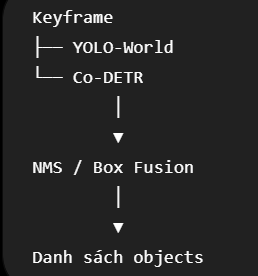

Output trung gian:

In [ ]:
{
  "video_id": "V001",
  "frames": [
    {
      "frame_id": "V001_00000_015",
      "shot_id": 0,
      "position": 0.15,
      "objects": [
        {
          "label": "person",
          "score": 0.95,
          "box": [100, 50, 300, 450],
          "area": 80000.0
        }
      ]
    }
  ]
}

Module Indexing chấp nhận cả hai cách đặc tên:
- score hoặc confidence
- box hoặc bbox

Output cuối trong SQLite

In [ ]:
CREATE TABLE objects (
    id           INTEGER PRIMARY KEY AUTOINCREMENT,
    frame_id     TEXT NOT NULL,
    label        TEXT NOT NULL,
    confidence   REAL NOT NULL,
    x_min        REAL NOT NULL,
    y_min        REAL NOT NULL,
    x_max        REAL NOT NULL,
    y_max        REAL NOT NULL,
    model_source TEXT,
    FOREIGN KEY (frame_id)
        REFERENCES metadata(frame_id)
        ON DELETE CASCADE
);

Ví dụ một frame có 3 người:
- 3 rows có: frame_id = cùng một giá trị, label = "person"
- Do đó count object được tính bằng:

In [ ]:
SELECT COUNT(*)
FROM objects
WHERE frame_id = ?
  AND label = 'person';

# 6. Text Embedding

Input:
- ASR cleaned transcipt
- Video summary
- OCR text

Model mặc định: dangvantuan/vietnamese-embedding. Vector được L2-normalize. Summary dài được xử lý bằng chunking rồi mean-pooling

**ASR embedding output**
- video_id: str
- interval_id: str
- start_time_sec: float
- end_time_sec: float
- text: str
- embedding: list[float]

Ví dụ:

In [ ]:
{
  "video_id": "V001",
  "interval_id": "interval_0001",
  "start_time_sec": 10.2,
  "end_time_sec": 17.8,
  "text": "Lũ lụt tại miền Trung...",
  "embedding": [0.012, -0.023]
}

**Summary embedding output**
- video_id: str
- text: str
- embedding: list[float]

**OCR embedding output**
- video_id: str
- frame_id: str
- shot_id
- text: str
- embedding: list[float]

**Thắc mắc**

Module 6 có sinh OCR embedding, nhưng Module 7 hiện chỉ load: text_asr, text_summary. Không có Milvus collection cho OCR embedding. Do đó Phase Online hiện có OCR lexical search trong Elasticsearch nhưng chưa có OCR semantic search trong Milvus

**Output cuối trong Milvus**

`asr_features`:
- pk: INT64 auto_id
- video_id: VARCHAR(512)
- interval_id: VARCHAR(256)
- start_time_sec: FLOAT
- end_time_sec: FLOAT
- embedding: FLOAT_VECTOR(768)

`summary_features`:
- pk: INT64 auto_id
- video_id: VARCHAR(512)
- embedding: FLOAT_VECTOR(768)

# 7. Multi-DB Indexing


Input:

Toàn bộ thư mục:

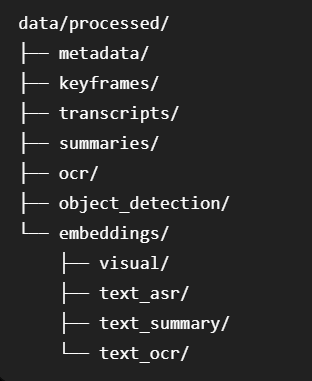

Xử lý trên từng video:
- Load toàn bộ artifact của video

→ xóa record cũ của video trong 3 DB

→ insert Milvus

→ insert Elasticsearch

→ insert SQLite

- Nếu Elasticsearch lỗi sau khi Milvus đã insert thì rollback Milvus
- Nếu SQLite lỗi thì rollback Milvus => Elasticsearch

**Output cuối**
- Milvus: 
    - visual_features
    - asr_features
    - summary_features
- Elasticsearch:
    - ocr_texts
    - asr_transcripts
    - video_summaries
- SQLite:
    - data/metadata.db

    => metadata

    => objects

# 8. VẤN ĐỀ `frame_id` bắt buộc giải quyết trước Online



Module 2 và Module 4 mô tả `frame_id` như: V001_00000_015 nhưng Module Indexing tạo SQLite `frame_id` từ tên file: shot_00000_pos_015

- Như vậy có khả năng:
    - Milvus: V001_00000_015
    - Elasticsearch: V001_00000_015
    - SQLite: shot_00000_pos_015
- Nếu đúng như vậy thì: Milvus.frame_id != SQLite.frame_id và JOIN sẽ thất bại
- Trước khi viết Retrieval Cord phải query một record thật
    - Milvus visual_features.frame_id
    - Elasticsearch ocr_texts.frame_id
    - SQLite metadata.frame_id
